In [1]:
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
import numpy as np
import solidspy.assemutil as ass

import utils.periodic_fem as periodic_fem

periodic_fem = importlib.reload(periodic_fem)

IMAGE_DATASET_PATH = Path("data/binary_image_dataset.npz")
RESULTS_PATH = Path("data/single_periodic_fem_results.npz")
IMAGE_INDEX = 0
LOAD_MODE = "tension_x"
BASE_DISPLACEMENT = 1.0
MACRO_DISPLACEMENT = 0.64

materials = np.array([
    [831e6, 0.35],
    [12e9, 0.27],
])

In [9]:
with np.load(IMAGE_DATASET_PATH) as dataset:
    image = dataset["images"][IMAGE_INDEX]

nodes = periodic_fem.create_node_grid(image)
elements = periodic_fem.create_element_topology(image).astype(int)
assembly_operator, boundary_conditions, equation_count = ass.DME(
    nodes[:, -2:], elements
)
stiffness_matrix, _ = ass.assembler(
    elements,
    materials,
    nodes[:, :3],
    equation_count,
    assembly_operator,
)

reference_nodes, image_nodes = periodic_fem.identify_periodic_nodes(nodes)
reference_dofs, reference_dof_map = periodic_fem.create_node_dof_map(reference_nodes)
image_dofs, image_dof_map = periodic_fem.create_node_dof_map(image_nodes)
total_dofs = 2 * len(nodes)
reduced_dofs = periodic_fem.reassign_periodic_dofs(
    total_dofs, image_dofs, reference_dofs
)

load_modes = ("tension_x", "tension_y", "shear")
load_case_results = {}
strain_cases = []
stress_cases = []

for mode in load_modes:
    transformation, prescribed = periodic_fem.build_periodic_transformation(
        base_displacement=BASE_DISPLACEMENT,
        total_dofs=total_dofs,
        reference_nodes=reference_nodes,
        image_nodes=image_nodes,
        reference_dofs=reference_dofs,
        image_dofs=image_dofs,
        reference_dof_map=reference_dof_map,
        image_dof_map=image_dof_map,
        reduced_dofs=reduced_dofs,
        nodes=nodes,
        mode=mode,
        displacement=MACRO_DISPLACEMENT,
    )
    case_displacement, case_strain, case_stress = periodic_fem.solve_periodic_load_case(
        stiffness_matrix,
        boundary_conditions,
        nodes,
        elements,
        materials,
        transformation,
        prescribed,
    )
    load_case_results[mode] = (case_displacement, case_strain, case_stress)
    strain_cases.append(case_strain.T)
    stress_cases.append(case_stress.T)

displacement, strain, stress = load_case_results[LOAD_MODE]
strain_cases_matrix = np.concatenate(strain_cases, axis=1)
stress_cases_matrix = np.concatenate(stress_cases, axis=1)
strain_cases_matrix[2, :] *= 0.5
coefficient_matrix = (
    stress_cases_matrix
    @ strain_cases_matrix.T
    @ np.linalg.pinv(strain_cases_matrix @ strain_cases_matrix.T)
)
coefficient_matrix = 0.5 * (coefficient_matrix + coefficient_matrix.T)

print(f"Image index: {IMAGE_INDEX}")
print(f"Displayed load mode: {LOAD_MODE}")
print(f"Nodes: {len(nodes)}, elements: {len(elements)}")
print("Coefficient matrix C (GPa):")
print(coefficient_matrix / 1e9)

Image index: 0
Displayed load mode: tension_x
Nodes: 4225, elements: 4096
Coefficient matrix C (GPa):
[[ 2.79142698  1.54886782 -0.49557731]
 [ 1.54886782  3.01140947 -0.80125198]
 [-0.49557731 -0.80125198  0.88775859]]


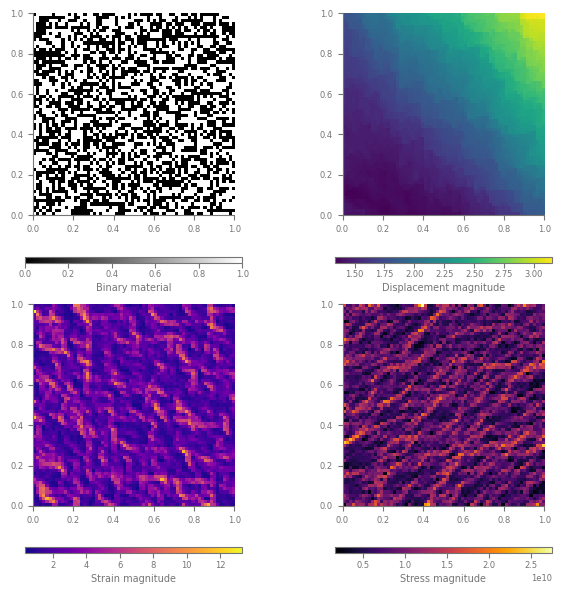

Maximum displacement: 3.152933e+00
Maximum strain: 1.333307e+01
Maximum stress: 2.752864e+10
Results saved to: data/single_periodic_fem_results.npz


In [41]:
element_nodes = elements[:, 3:].astype(int)
displacement_vectors = displacement.reshape(-1, 2)
displacement_magnitude = np.linalg.norm(displacement_vectors, axis=1)
strain_magnitude = np.linalg.norm(strain, axis=1)
stress_magnitude = np.linalg.norm(stress, axis=1)

if not all(
    np.all(np.isfinite(field))
    for field in (displacement, strain, stress, coefficient_matrix)
):
    raise ValueError("The FEM solution contains NaN or infinite values.")

node_count_per_side = image.shape[0] + 1
node_extent = (
    nodes[:, 1].min(),
    nodes[:, 1].max(),
    nodes[:, 2].min(),
    nodes[:, 2].max(),
)

fig = plt.figure(figsize=(6.5, 6.0))
grid = fig.add_gridspec(
    nrows=4,
    ncols=4,
    height_ratios=(1, 0.03, 1, 0.03),
    hspace=0.4,
    wspace=0.22,
)

map_specs = (
    (0, 0, image, "gray", "Binary material"),
    (0, 2, displacement_magnitude.reshape(node_count_per_side, node_count_per_side), "viridis", "Displacement magnitude"),
    (2, 0, strain_magnitude.reshape(node_count_per_side, node_count_per_side), "plasma", "Strain magnitude"),
    (2, 2, stress_magnitude.reshape(node_count_per_side, node_count_per_side), "inferno", "Stress magnitude"),
)

for row, column, field, colormap, colorbar_label in map_specs:
    axis = fig.add_subplot(grid[row, column:column + 2])
    colorbar_grid = grid[row + 1, column:column + 2].subgridspec(
        1,
        3,
        width_ratios=(1, 14, 1),
    )
    colorbar_axis = fig.add_subplot(colorbar_grid[0, 1])
    image_plot = axis.imshow(
        field,
        origin="lower",
        extent=node_extent,
        cmap=colormap,
        interpolation="none",
        aspect="equal",
    )
    axis.tick_params(labelsize=6)
    colorbar = fig.colorbar(image_plot, cax=colorbar_axis, orientation="horizontal")
    colorbar.set_label(colorbar_label, fontsize=7, labelpad=3)
    colorbar.ax.tick_params(labelsize=6, pad=1.8)
    colorbar.ax.xaxis.get_offset_text().set_fontsize(6)

fig.subplots_adjust(left=0.07, right=0.98, bottom=0.08, top=0.98)
plt.show()

np.savez_compressed(
    RESULTS_PATH,
    image_index=IMAGE_INDEX,
    load_mode=LOAD_MODE,
    displacement=displacement,
    strain=strain,
    stress=stress,
    coefficient_matrix=coefficient_matrix,
)

print(f"Maximum displacement: {displacement_magnitude.max():.6e}")
print(f"Maximum strain: {strain_magnitude.max():.6e}")
print(f"Maximum stress: {stress_magnitude.max():.6e}")
print(f"Results saved to: {RESULTS_PATH}")